In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Load road network
roads = gpd.read_file(r"C:\Users\lstojano\Desktop\teza\road_extraction_slovenia\data\raw\roads\roads_102109.gpkg")

# Basic info
print("Shape:", roads.shape)
print("\nColumns:", roads.columns.tolist())
print("\nCRS:", roads.crs)

Shape: (498431, 16)

Columns: ['TN_DTM_ID', 'ST_CES', 'KAT_CES', 'VRSTA_CES', 'USTROJ_CES', 'TIPOBJ_CES', 'SIRCES', 'SIRVOZ', 'STANJE_CES', 'MET_ZAJ', 'DVIR', 'ID_IME', 'IME', 'Ces_Val', 'Cest_Val', 'geometry']

CRS: PROJCS["ETRS_1989_Slovenia_TM",GEOGCS["ETRS89",DATUM["European_Terrestrial_Reference_System_1989",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6258"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4258"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",15],PARAMETER["scale_factor",0.9999],PARAMETER["false_easting",500000],PARAMETER["false_northing",-5000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["ESRI","102109"]]


In [2]:
# Explore KAT_CES - road category field
print("=== KAT_CES (Road Category) ===")
print(roads['KAT_CES'].value_counts().to_string())

print("\n=== SIRCES (Road Width Code) ===")
print(roads['SIRCES'].value_counts().sort_index().to_string())

print("\n=== SIRVOZ (Carriageway Width) ===")
print(roads['SIRVOZ'].value_counts().sort_index().to_string())

print("\n=== Any missing values? ===")
print(roads[['KAT_CES', 'SIRCES', 'SIRVOZ']].isnull().sum())

=== KAT_CES (Road Category) ===
KAT_CES
NK    405654
JP     25035
LC     19249
LG     18214
GZ     10179
R3      3599
R2      3259
AC      2733
LK      2290
R1      2068
PP      1707
LZ      1200
G2      1045
G1       840
HC       625
RT       620
KJ       111
KD         1

=== SIRCES (Road Width Code) ===
SIRCES
0.0          1
1.0       3848
2.0     238170
3.0     155600
4.0      45113
5.0      21694
6.0      13442
7.0       7149
8.0       5079
9.0       2385
10.0      1928
11.0      1490
12.0       996
13.0       359
14.0       337
15.0       254
16.0       152
17.0        80
18.0        68
19.0        67
20.0        82
21.0        11
22.0        27
23.0        16
24.0         2
25.0        41
26.0         9
27.0         9
28.0         2
30.0         5
31.0         3
32.0         1
33.0         5
37.0         3
39.0         3

=== SIRVOZ (Carriageway Width) ===
SIRVOZ
0.0          2
1.0       3849
2.0     239072
3.0     159469
4.0      46148
5.0      24339
6.0      14099
7.0       51

In [3]:
# Cross-tabulate KAT_CES vs SIRCES statistics
print("=== Average SIRCES width per road category ===")
summary = roads.groupby('KAT_CES')['SIRCES'].agg(['mean', 'median', 'min', 'max', 'count'])
summary = summary.round(2).sort_values('mean', ascending=False)
print(summary.to_string())

print("\n=== Class mapping preview ===")
class_map = {
    'AC': 1, 'HC': 1, 'G1': 1, 'G2': 1, 'R1': 1, 'GZ': 1,
    'R2': 2, 'R3': 2, 'RT': 2, 'LC': 2, 'LZ': 2,
    'LG': 3, 'LK': 3, 'JP': 3, 'KD': 3, 'KJ': 3, 'NK': 3, 'PP': 3
}
roads['road_class'] = roads['KAT_CES'].map(class_map)
print(roads['road_class'].value_counts().sort_index())
print("\nUnmapped (NaN):", roads['road_class'].isna().sum())

=== Average SIRCES width per road category ===
         mean  median  min   max   count
KAT_CES                                 
G1       8.35     8.0  3.0  30.0     840
AC       8.34     8.0  3.0  22.0    2733
LZ       7.93     7.0  1.0  37.0    1200
HC       7.90     8.0  4.0  18.0     625
G2       7.59     7.0  2.0  23.0    1045
R1       7.48     7.0  3.0  22.0    2068
R2       7.39     7.0  2.0  20.0    3259
LK       6.53     5.0  2.0  37.0    2290
R3       6.10     6.0  2.0  20.0    3599
RT       5.14     5.0  3.0  12.0     620
LC       4.55     4.0  2.0  23.0   19249
KD       4.00     4.0  4.0   4.0       1
JP       3.67     3.0  1.0  33.0   25035
LG       3.32     3.0  2.0  33.0   18214
KJ       3.23     3.0  1.0   7.0     111
GZ       2.80     3.0  1.0   9.0   10179
NK       2.70     2.0  0.0  39.0  405654
PP       1.89     2.0  1.0  10.0    1707

=== Class mapping preview ===
road_class
1.0     17490
2.0     27927
3.0    453012
Name: count, dtype: int64

Unmapped (NaN): 2


In [4]:
# Analyze buffer values we would generate per class
roads_clean = roads[roads['KAT_CES'].notna()].copy()
roads_clean['road_class'] = roads_clean['KAT_CES'].map({
    'AC': 1, 'HC': 1, 'G1': 1, 'G2': 1, 'R1': 1,
    'GZ': 2, 'R2': 2, 'R3': 2, 'RT': 2, 'LC': 2, 'LZ': 2,
    'LG': 3, 'LK': 3, 'JP': 3, 'KD': 3, 'KJ': 3, 'NK': 3, 'PP': 3
})

# Replace SIRCES=0 with NaN for analysis
roads_clean['SIRCES_clean'] = roads_clean['SIRCES'].replace(0, float('nan'))

# Calculate half-width buffer per class
print("=== Buffer analysis (SIRCES / 2) per class ===")
for cls in [1, 2, 3]:
    subset = roads_clean[roads_clean['road_class'] == cls]['SIRCES_clean']
    print(f"\nClass {cls}:")
    print(f"  Count:          {len(subset)}")
    print(f"  Mean buffer:    {(subset.mean()/2):.2f} m")
    print(f"  Median buffer:  {(subset.median()/2):.2f} m")
    print(f"  Min buffer:     {(subset.min()/2):.2f} m")
    print(f"  Max buffer:     {(subset.max()/2):.2f} m")
    print(f"  SIRCES=0 count: {(roads_clean[roads_clean['road_class']==cls]['SIRCES']==0).sum()}")
    print(f"  SIRCES=1 count: {(roads_clean[roads_clean['road_class']==cls]['SIRCES']==1).sum()}")

=== Buffer analysis (SIRCES / 2) per class ===

Class 1:
  Count:          7311
  Mean buffer:    3.98 m
  Median buffer:  4.00 m
  Min buffer:     1.00 m
  Max buffer:     15.00 m
  SIRCES=0 count: 0
  SIRCES=1 count: 0

Class 2:
  Count:          38106
  Mean buffer:    2.29 m
  Median buffer:  2.00 m
  Min buffer:     0.50 m
  Max buffer:     18.50 m
  SIRCES=0 count: 0
  SIRCES=1 count: 6

Class 3:
  Count:          453012
  Mean buffer:    1.40 m
  Median buffer:  1.00 m
  Min buffer:     0.50 m
  Max buffer:     19.50 m
  SIRCES=0 count: 1
  SIRCES=1 count: 3842


In [5]:
# How many segments are BELOW minimum threshold per class?
minimums = {1: 3.0, 2: 2.0, 3: 1.5}

print("=== Segments below minimum buffer threshold ===")
for cls in [1, 2, 3]:
    subset = roads_clean[roads_clean['road_class'] == cls].copy()
    subset['buffer'] = (subset['SIRCES'] / 2).clip(lower=0)
    subset['buffer'] = subset['buffer'].replace(0, subset['buffer'].median())
    
    below = (subset['buffer'] < minimums[cls]).sum()
    total = len(subset)
    print(f"\nClass {cls} (min={minimums[cls]}m):")
    print(f"  Total segments:        {total}")
    print(f"  Below minimum:         {below} ({100*below/total:.1f}%)")
    print(f"  Will be clipped up to minimum: {below} segments")

print("\n=== Final buffer strategy summary ===")
print("Buffer = max(SIRCES/2, class_minimum)")
print("SIRCES=0 replaced with class median before calculation")

=== Segments below minimum buffer threshold ===

Class 1 (min=3.0m):
  Total segments:        7311
  Below minimum:         1078 (14.7%)
  Will be clipped up to minimum: 1078 segments

Class 2 (min=2.0m):
  Total segments:        38106
  Below minimum:         13450 (35.3%)
  Will be clipped up to minimum: 13450 segments

Class 3 (min=1.5m):
  Total segments:        453012
  Below minimum:         238403 (52.6%)
  Will be clipped up to minimum: 238403 segments

=== Final buffer strategy summary ===
Buffer = max(SIRCES/2, class_minimum)
SIRCES=0 replaced with class median before calculation


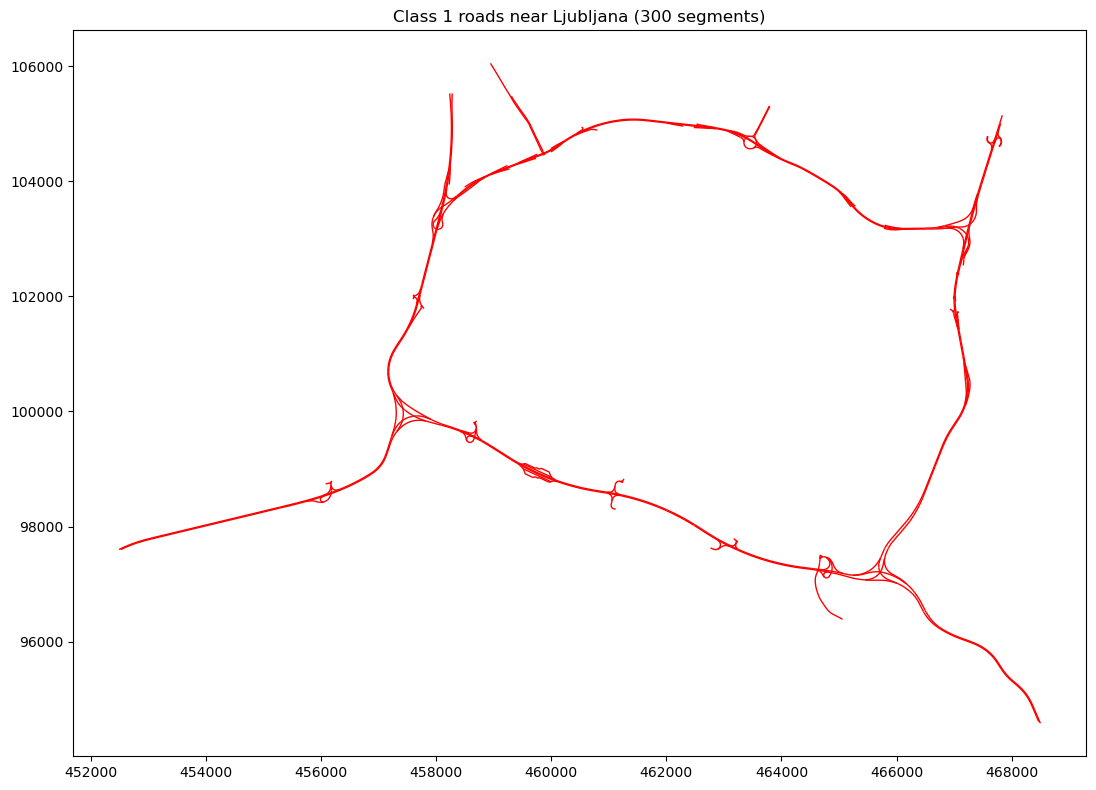

Segments shown: 300


In [6]:
# Check Ljubljana highway area for dual carriageway
import matplotlib.pyplot as plt

# Filter just Class 1 roads in Ljubljana area
lj_bbox = (455000, 95000, 470000, 105000)
major = roads_clean[roads_clean['road_class'] == 1].cx[
    lj_bbox[0]:lj_bbox[2], 
    lj_bbox[1]:lj_bbox[3]
]

fig, ax = plt.subplots(figsize=(12, 8))
major.plot(ax=ax, color='red', linewidth=1)
ax.set_title(f'Class 1 roads near Ljubljana ({len(major)} segments)')
plt.tight_layout()
plt.savefig('test_major_roads.png', dpi=100)
plt.show()
print(f"Segments shown: {len(major)}")

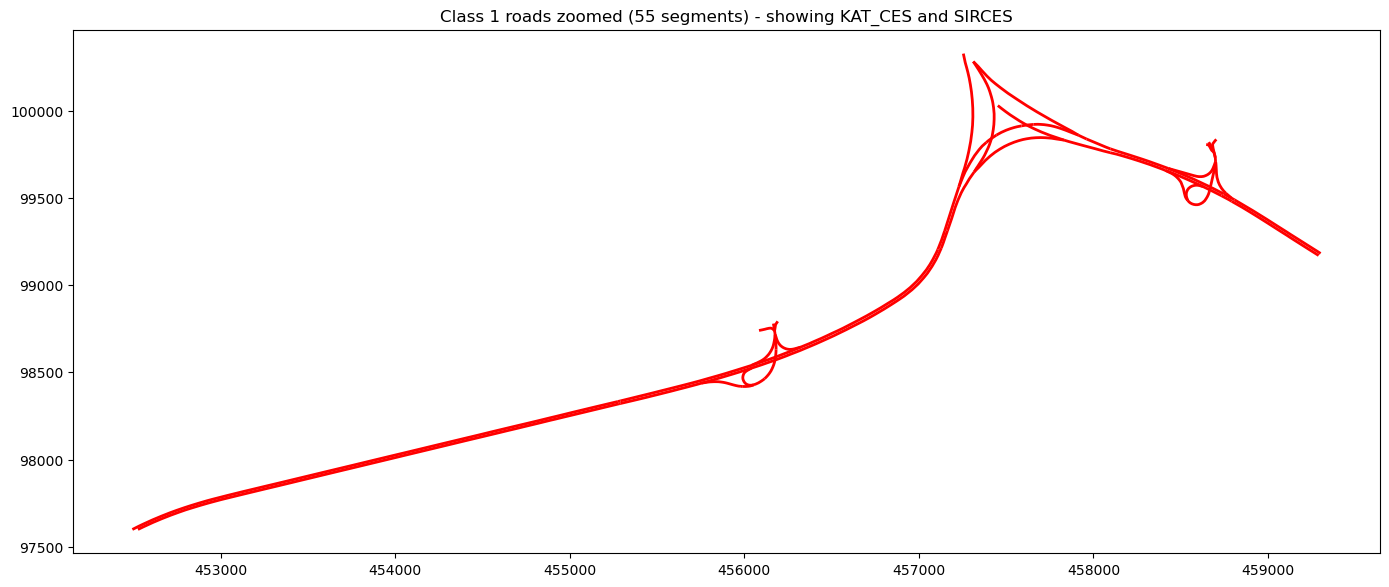

Segments shown: 55


In [7]:
# Zoom into a small area of the A1 motorway west of Ljubljana
zoom_bbox = (455000, 98000, 459000, 100000)
major_zoom = roads_clean[roads_clean['road_class'] == 1].cx[
    zoom_bbox[0]:zoom_bbox[2],
    zoom_bbox[1]:zoom_bbox[3]
]

fig, ax = plt.subplots(figsize=(14, 8))
major_zoom.plot(ax=ax, color='red', linewidth=2)

# Add labels showing SIRCES value for each segment
for idx, row in major_zoom.iterrows():
    if row.geometry.geom_type == 'LineString':
        mid = row.geometry.interpolate(0.5, normalized=True)
        ax.annotate(f"{row['KAT_CES']}\n{row['SIRCES']}m", 
                   xy=(mid.x, mid.y),
                   fontsize=7, color='blue',
                   ha='center')

ax.set_title(f'Class 1 roads zoomed ({len(major_zoom)} segments) - showing KAT_CES and SIRCES')
plt.tight_layout()
plt.savefig('test_major_roads_zoom.png', dpi=150)
plt.show()
print(f"Segments shown: {len(major_zoom)}")

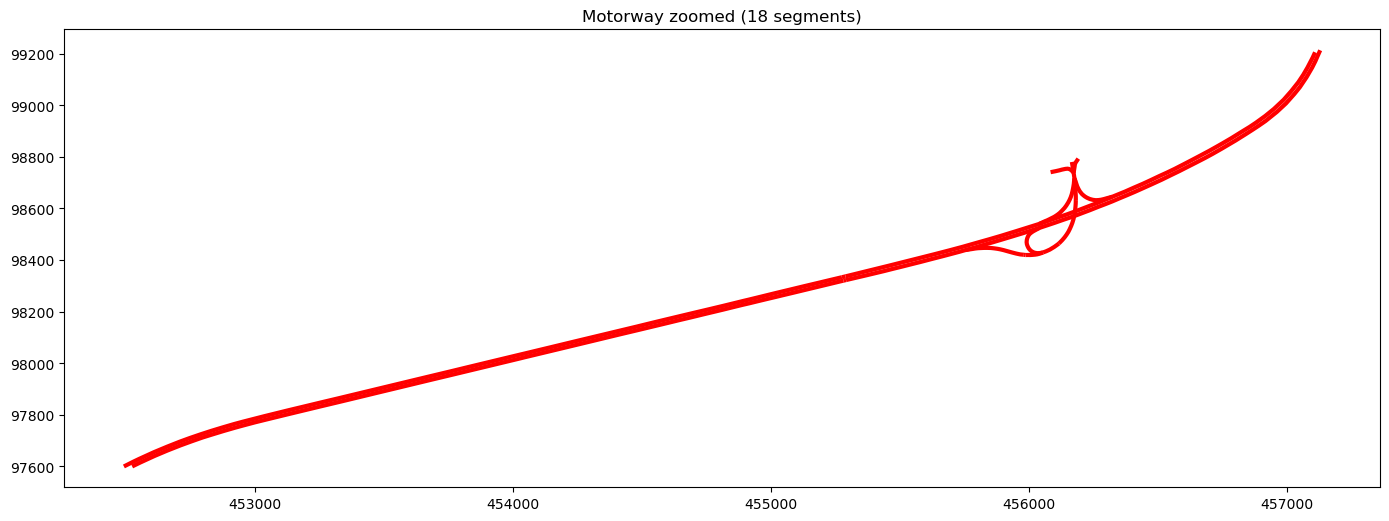

       KAT_CES  SIRCES   IME
373648      AC     7.0  None
374484      AC     5.0  None
374485      AC     5.0  None
374486      AC     4.0  None
374866      AC    11.0  None
374868      AC     5.0  None
374871      AC    12.0  None
376380      AC     8.0  None
376381      AC     5.0  None
376382      AC     7.0  None
376383      AC     5.0  None
376922      AC     5.0  None
376923      AC     5.0  None
378875      AC    11.0  None
378876      AC    11.0  None
385258      AC    11.0  None
393748      AC    11.0  None
415163      AC    11.0  None


In [8]:
# Zoom into just the straight motorway section
zoom_bbox2 = (453000, 97500, 456500, 98800)
major_zoom2 = roads_clean[roads_clean['road_class'] == 1].cx[
    zoom_bbox2[0]:zoom_bbox2[2],
    zoom_bbox2[1]:zoom_bbox2[3]
]

fig, ax = plt.subplots(figsize=(14, 6))
major_zoom2.plot(ax=ax, color='red', linewidth=3)

for idx, row in major_zoom2.iterrows():
    if row.geometry.geom_type == 'LineString':
        mid = row.geometry.interpolate(0.5, normalized=True)
        ax.annotate(f"{row['KAT_CES']} {row['SIRCES']}m", 
                   xy=(mid.x, mid.y),
                   fontsize=9, color='blue',
                   ha='center',
                   bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.7))

ax.set_title(f'Motorway zoomed ({len(major_zoom2)} segments)')
plt.tight_layout()
plt.savefig('test_motorway_detail.png', dpi=150)
plt.show()
print(major_zoom2[['KAT_CES', 'SIRCES', 'IME']].to_string())